# Supplementary Figure: Tested Bin Performance with Confidence Intervals

Description: Model performance comparison across different bin configurations with 95% confidence intervals. The grouped bar chart shows mean classification performance across five metrics: Accuracy, F1 score, Recall, Precision, and AUROC. Within each metric group, bars correspond to tested histogram bin sizes (five, ten, fifteen, and twenty bins), distinguished by both color and hatch pattern. Error bars show 95% confidence intervals estimated from repeated runs with different random seeds using a t-distribution. The y-axis is zoomed to the observed performance range to make small differences between configurations easier to compare. Overall, the ten-bin setting shows a slight performance edge, most clearly in Precision and among the top values for Accuracy and F1 score.

Alt text: Grouped bar chart of model performance across Accuracy, F1 score, Recall, Precision, and AUROC. Each metric includes four bars for five, ten, fifteen, and twenty bins, with each bin setting identified by a unique color and hatch pattern. All bars are high and close together, with narrow ninety-five percent confidence intervals. The ten-bin bars are slightly higher overall, especially for Precision.

In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem, t

# NOTE: Evaluation naming changed from stacking_* to binned_*; this notebook supports both patterns.
FS_TITLE = 13
FS_SUBTITLE = 12
FS_LABEL = 12
FS_TICK = 12
FS_LEGEND = 12
FS_TEXT = 12

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_TEXT,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results' / 'eval_once_bins_5_10_15_20_t05'
figures_dir = base_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

pattern = re.compile(r'(?:binned|stacking_bin)_(\d+)_iteration_metrics\.csv$')
iteration_metric_files = sorted(
    (path for path in results_dir.glob('*_iteration_metrics.csv') if pattern.search(path.name)),
    key=lambda path: int(pattern.search(path.name).group(1)),
)

if not iteration_metric_files:
    raise FileNotFoundError(
        f'No binned/stacking bin iteration metric files found in: {results_dir}'
    )

print(f'Using results directory: {results_dir}')
print('Found tested bin files:')
for path in iteration_metric_files:
    print(f'  - {path.name}')

Using results directory: /home/tobamo/analize/project-tobamo/analysis/model/results/eval_once_bins_5_10_15_20_t05
Found tested bin files:
  - stacking_bin_5_iteration_metrics.csv
  - stacking_bin_10_iteration_metrics.csv
  - stacking_bin_15_iteration_metrics.csv
  - stacking_bin_20_iteration_metrics.csv


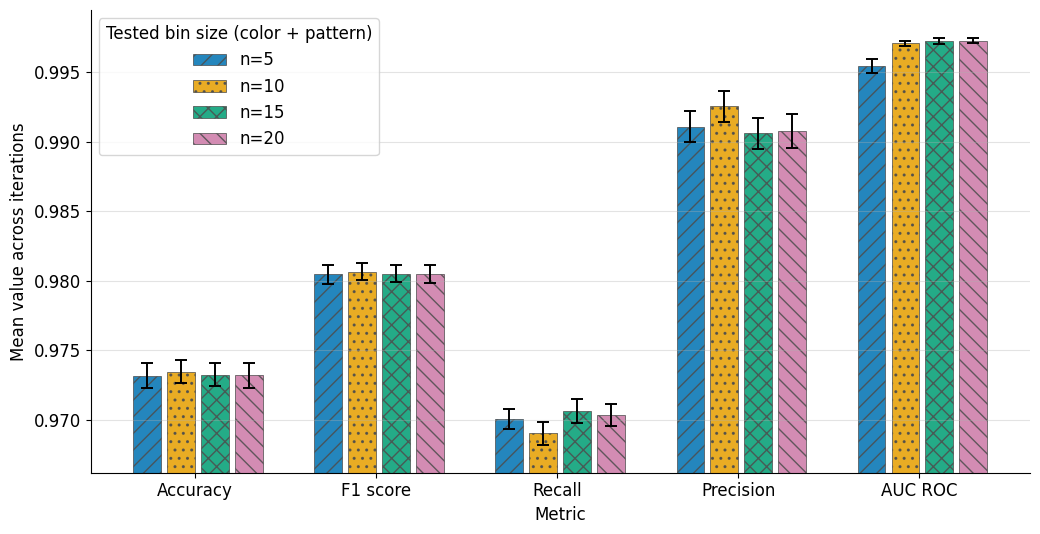

Saved figure to: /home/tobamo/analize/project-tobamo/analysis/model/figures/supp_fig4_bin_test.png
Tested bin values: [np.int64(5), np.int64(10), np.int64(15), np.int64(20)]


,n,metric,metric_label,mean,std,ci_lower,ci_upper
0,5,accuracy,Accuracy,0.9732,0.0024,0.9723,0.9741
1,5,f1,F1 score,0.9804,0.0018,0.9798,0.9811
2,5,recall,Recall,0.9701,0.0019,0.9694,0.9708
3,5,precision,Precision,0.9911,0.0029,0.9900,0.9922
4,5,auc,AUC ROC,0.9954,0.0013,0.9949,0.9959
5,10,accuracy,Accuracy,0.9735,0.0023,0.9726,0.9743
6,10,f1,F1 score,0.9806,0.0016,0.9800,0.9812
7,10,recall,Recall,0.9690,0.0022,0.9682,0.9699
8,10,precision,Precision,0.9925,0.0029,0.9914,0.9936
9,10,auc,AUC ROC,0.9971,0.0005,0.9969,0.9972


In [6]:
metric_specs = [
    ('accuracy', 'Accuracy'),
    ('f1', 'F1 score'),
    ('recall', 'Recall'),
    ('precision', 'Precision'),
    ('auc', 'AUC ROC'),
]

iteration_frames = []
for path in iteration_metric_files:
    match = pattern.search(path.name)
    n_value = int(match.group(1))
    frame = pd.read_csv(path)
    frame['n'] = n_value
    iteration_frames.append(frame)

metrics_df = pd.concat(iteration_frames, ignore_index=True)

confidence_level = 0.95
summary_rows = []
for n_value, grp in metrics_df.groupby('n', sort=True):
    for metric_key, metric_label in metric_specs:
        vals = grp[metric_key].to_numpy(dtype=float)
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else 0.0
        se = sem(vals) if len(vals) > 1 else 0.0
        h = se * t.ppf((1 + confidence_level) / 2, len(vals) - 1) if len(vals) > 1 else 0.0
        summary_rows.append({
            'n': n_value,
            'metric': metric_key,
            'metric_label': metric_label,
            'mean': mean,
            'std': std,
            'ci_lower': mean - h,
            'ci_upper': mean + h,
        })

summary_df = pd.DataFrame(summary_rows)
bins = sorted(summary_df['n'].unique())

means = np.array([
    [summary_df[(summary_df['n'] == n_value) & (summary_df['metric'] == metric_key)]['mean'].iloc[0] for metric_key, _ in metric_specs]
    for n_value in bins
])
ci_lowers = np.array([
    [summary_df[(summary_df['n'] == n_value) & (summary_df['metric'] == metric_key)]['ci_lower'].iloc[0] for metric_key, _ in metric_specs]
    for n_value in bins
])
ci_uppers = np.array([
    [summary_df[(summary_df['n'] == n_value) & (summary_df['metric'] == metric_key)]['ci_upper'].iloc[0] for metric_key, _ in metric_specs]
    for n_value in bins
])

lower_err = means - ci_lowers
upper_err = ci_uppers - means

x = np.arange(len(metric_specs))
slot_width = 0.75 / len(bins)
bar_width = slot_width * 0.82
y_min = max(0.0, ci_lowers.min() - 0.002)
y_max = min(1.0, ci_uppers.max() + 0.002)
colorblind_palette = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']
bin_colors = colorblind_palette[:len(bins)]
hatch_cycle = ['//', '..', 'xx', '\\\\', '++', 'oo']

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, n_value in enumerate(bins):
    x_pos = x + i * slot_width + (slot_width - bar_width) / 2
    bars = ax.bar(
        x_pos,
        means[i],
        bar_width,
        yerr=[lower_err[i], upper_err[i]],
        capsize=4,
        alpha=0.86,
        color=bin_colors[i],
        edgecolor='#4d4d4d',
        linewidth=0.6,
        error_kw={'elinewidth': 1.4, 'ecolor': '#000000', 'capthick': 1.4},
        label=f'n={n_value}',
    )
    for bar in bars:
        bar.set_hatch(hatch_cycle[i % len(hatch_cycle)])

ax.set_xticks(x + slot_width * (len(bins) - 1) / 2)
ax.set_xticklabels([label for _, label in metric_specs], fontsize=FS_TICK)
ax.set_xlabel('Metric', fontsize=FS_LABEL)
ax.set_ylabel('Mean value across iterations', fontsize=FS_LABEL)
ax.set_ylim(y_min, y_max)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.grid(axis='y', alpha=0.35)
ax.legend(
    loc='upper left',
    fontsize=FS_LEGEND,
    title='Tested bin size (color + pattern)',
    title_fontsize=FS_LEGEND,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
output_path = figures_dir / 'supp_fig4_bin_test.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f'Saved figure to: {output_path}')
print(f'Tested bin values: {bins}')
display(summary_df.round(4))